## Load data and packages

In [917]:
import numpy as np
import pandas as pd   # We import Pandas!
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn import linear_model
import torch
import itertools

import pyro
import pyro.distributions as dist
from pyro.contrib.autoguide import AutoDiagonalNormal, AutoMultivariateNormal
from pyro.infer import MCMC, NUTS, HMC, SVI, Trace_ELBO
from pyro.optim import Adam, ClippedAdam

# fix random generator seed (for reproducibility of results)
np.random.seed(42)

# matplotlib options
palette = itertools.cycle(sns.color_palette())
plt.style.use('ggplot')
%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 10)

In [918]:
df_train= pd.read_csv('../data/movies_with_genres_and_cast_train.csv')
df_test= pd.read_csv('../data/movies_with_genres_and_cast_test.csv')

#To test different ranges, must be higher than 1969
Start_year = 2000
df_train=df_train[df_train["year"] >= Start_year]
df_test=df_test[df_test["year"] >= Start_year]

# Model 1: Release date, genres and budget regression model

The first model is a very simple regression model. In this first model, we will use as features the day of release within a year, the genres, and the budget of the movie.
As for all of the other models, the target variable is the inflated movie revenue y.

Since we use four different models, it is easier to direcly split the data table into the train set and test set. This will also ensure comparable results. For this reason, the preparation of the data will be done for both the train and test sets.

### Prepare features and target variable

The first feature is $X_{time}$. This feature will reflect the influence of the day of the year on the revenue of the movie. Since revenue is not a linear function of the days of the year, we will 1-of-K encoding to allow non-linear relationship. However, 1-of-K encoding with all of the days would mean 365 dummies, and it won't be relevant to showcase the influence of a period of the year. Instead, weeks and days of the week (dow) are selected.

In [919]:
X_time_train = np.concatenate([pd.get_dummies(df_train[x]).astype(float) for x in ["dow", "week"]], axis=1)
X_time_test = np.concatenate([pd.get_dummies(df_test[x]).astype(float) for x in ["dow", "week"]], axis=1)
print(X_time_train.shape, X_time_test.shape)
print(X_time_train[1])

(3200, 60) (671, 60)
[0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


The second feature is the $X_{movie}$. It will regroup all of the caracteristics of the movies that are considered here. This includes the genres of the movie, as well as the inflated budget. 

Only the 10 most occuring genres are considered here, and each movie can have none, as well as multiple genres within those. For the 10 genre dummies, the value in the data table is $\frac{1}{\text{Number of genre of the movie}}$ if the movie is of this genre, or 0 if not. This will permit a higher weight for the movies with a low number of genre.

In [920]:
movie_caracteristics = ["genre_drama" , "genre_comedy" , "genre_thriller",
 "genre_romance", "genre_action", "genre_horror", "genre_crime",
 "genre_documentary", "genre_adventure", "genre_science_fiction", "budget_inflated"]

X_movie_train = df_train[movie_caracteristics].copy()
X_movie_test = df_test[movie_caracteristics].copy()

X_movie_train = X_movie_train.apply(pd.to_numeric, errors='coerce')
X_movie_test = X_movie_test.apply(pd.to_numeric, errors='coerce')

# Convert to numpy
X_movie_train = X_movie_train.values
X_movie_test = X_movie_test.values

print(X_movie_train.shape)
print(X_movie_test.shape)
print(X_movie_train[1])

(3200, 11)
(671, 11)
[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 2.50000000e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
 2.50000000e-01 2.50000000e-01 4.33643486e+08]


Once this is done, we can concatenate $X_{time}$ and $X_{movie}$ in the final vector $X$ that will be used in the model, and we can standardize it based on the training set mean.

In [921]:
X_train = np.concatenate([X_time_train, X_movie_train], axis=1)
X_test = np.concatenate([X_time_test, X_movie_test], axis=1)
print(X_train.shape)
print(X_test.shape)


(3200, 71)
(671, 71)


In [922]:
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)
X_train = (X_train - X_mean) / X_std
X_test = (X_test - X_mean) / X_std


The target variable $y$ is also prepared and standardized for both the training and test set.

In [923]:
y_train = df_train["revenue_inflated"].values
y_test = df_test["revenue_inflated"].values

y_mean = y_train.mean()
y_std = y_train.std()
y_train = (y_train - y_mean) / y_std
y_test = (y_test - y_mean) / y_std

### Test and error mesurement

To mesure the errors of the model, we create a function that will be able to compute the corrcoef, MAE, RMSE, and R².

In [924]:
def compute_error(trues, predicted):
    corr = np.corrcoef(predicted, trues)[0,1]
    mae = np.mean(np.abs(predicted - trues))
    rmse = np.sqrt(np.mean((predicted - trues)**2))
    r2 = max(0, 1 - np.sum((trues-predicted)**2) / np.sum((trues - np.mean(trues))**2))
    return corr, mae, rmse, r2

First, we try a linear regression from Sklearn.

In [925]:
#regr = linear_model.LinearRegression()
regr = linear_model.Ridge()
regr.fit(X_train, y_train)
y_hat = regr.predict(X_test)

# Convert back to the original scale
y_pred = y_hat * y_std + y_mean
y_true = y_test * y_std + y_mean

corr, mae, rmse, r2 = compute_error(y_true, y_pred)
print("CorrCoef: %.3f\nMAE: %.3f\nRMSE: %.3f\nR2: %.3f" % (corr, mae, rmse, r2))

CorrCoef: 0.790
MAE: 78368297.492
RMSE: 130961954.230
R2: 0.613


### MODEL 1

The model is a basic linear regression model. A gaussian distribution was selected since it makes sense that the revenues of the films over time follows a normal distribution. An intercept $\alpha$ was explicitly modelled with a prior of 0 since everything is standardized. A regression coefficient $\beta$ and a constant variance $\sigma$ were also implemented. The target variable then follows this distribution:

$y \sim \mathcal{N}(\alpha + \beta^T x_n, \sigma^2)$

In [926]:
def release_genre_budget_model(X, obs=None):
    alpha = pyro.sample("alpha", dist.Normal(0, 1))                   
    beta  = pyro.sample("beta", dist.Normal(torch.zeros(X.shape[1]), 
                                            torch.ones(X.shape[1])).to_event())    
    sigma = pyro.sample("sigma", dist.HalfCauchy(0.5)) 
    
    with pyro.plate("data"):
        y = pyro.sample("y", dist.Normal(alpha + X.matmul(beta), sigma), obs=obs)
        
    return y

# Stochastic variational inference (SVI) training

To train this model on the data, we will use stochastic variational inference (SVI) on the training set. First, we transform the data into pytorch tensors.

In [927]:
# Prepare data for Pyro model
X_train_torch = torch.tensor(X_train).float()
y_train_torch = torch.tensor(y_train).float()

Then, we automatically define the function used to approximate.

In [928]:
# Define guide function
guide = AutoMultivariateNormal(release_genre_budget_model)

# Reset parameter values
pyro.clear_param_store()

We set the number of steps and the learning rate of the optimizer, trying different values.

In [929]:
# Define the number of optimization steps
n_steps = 4000

# Setup the optimizer
adam_params = {"lr": 0.001} # learning rate (lr) of optimizer
optimizer = ClippedAdam(adam_params)

# Setup the inference algorithm
elbo = Trace_ELBO(num_particles=1)
svi = SVI(release_genre_budget_model, guide, optimizer, loss=elbo)

Now that everything is ready, we can create a loop that will compute the evidence lower bound (ELBO) each time and make it converge.

In [930]:
# Do gradient steps
for step in range(n_steps):
    elbo = svi.step(X_train_torch, y_train_torch)
    if step % 100 == 0:
        print("[%d] ELBO: %.1f" % (step, elbo))

[0] ELBO: 105423.3


[100] ELBO: 78790.2
[200] ELBO: 37922.6
[300] ELBO: 21848.7
[400] ELBO: 17014.3
[500] ELBO: 7367.0
[600] ELBO: 5265.2
[700] ELBO: 4933.3
[800] ELBO: 4525.5
[900] ELBO: 4176.8
[1000] ELBO: 4331.1
[1100] ELBO: 4194.6
[1200] ELBO: 3933.8
[1300] ELBO: 3947.8
[1400] ELBO: 3813.0
[1500] ELBO: 3716.6
[1600] ELBO: 3785.4
[1700] ELBO: 3706.6
[1800] ELBO: 3645.1
[1900] ELBO: 3628.8
[2000] ELBO: 3594.7
[2100] ELBO: 3588.1
[2200] ELBO: 3590.0
[2300] ELBO: 3506.9
[2400] ELBO: 3514.5
[2500] ELBO: 3473.6
[2600] ELBO: 3481.9
[2700] ELBO: 3449.3
[2800] ELBO: 3478.7
[2900] ELBO: 3496.9
[3000] ELBO: 3486.5
[3100] ELBO: 3477.7
[3200] ELBO: 3449.0
[3300] ELBO: 3426.0
[3400] ELBO: 3432.6
[3500] ELBO: 3430.8
[3600] ELBO: 3424.5
[3700] ELBO: 3411.6
[3800] ELBO: 3425.4
[3900] ELBO: 3409.0


Once we have the convergence of the ELBO, we can use the Predictive function from pyro.infer to retrieve the values of the inferred parameters $\alpha$, $\beta$ and $\sigma$.

In [931]:
from pyro.infer import Predictive

predictive = Predictive(release_genre_budget_model, guide=guide, num_samples=5000,
                        return_sites=("alpha", "beta", "sigma"))
samples = predictive(X_train_torch, y_train_torch)
print(samples["alpha"].shape)

alpha_samples = samples["alpha"].detach().numpy()
beta_samples = samples["beta"].detach().numpy()
sigma_samples = samples["sigma"].detach().numpy()

torch.Size([5000, 1])


Once we have the inferred parameters, we can comput $\hat{y}$, the standardized prediction. Then, we convert it back to the original scale.

In [936]:
y_hat = np.mean(alpha_samples.T + np.dot(X_test, beta_samples[:,0].T), axis=1)

y_pred = y_hat * y_std + y_mean
y_true = y_test * y_std + y_mean

print(y_pred.size)

671


With the true value of the test set, and the predicted value, we can calculate the errors that we have. We will also compute a baseline for both the MAE and RMSE.

In [937]:
corr, mae, rmse, r2 = compute_error(y_true, y_pred)
print("CorrCoef: %.3f\nMAE: %.3f\nRMSE: %.3f\nR2: %.3f" % (corr, mae, rmse, r2))

y_true = torch.tensor(y_true).float()

baseline_pred = torch.zeros_like(y_true)
baseline_mae = torch.mean(torch.abs(baseline_pred - y_true))
baseline_rmse = torch.sqrt(torch.mean((baseline_pred - y_true) ** 2))
print("Baseline MAE: %.3f\nBaseline RMSE: %.3f" % (baseline_mae, baseline_rmse))

CorrCoef: 0.789
MAE: 79013378.676
RMSE: 131318832.843
R2: 0.611
Baseline MAE: 112585272.000
Baseline RMSE: 238655200.000


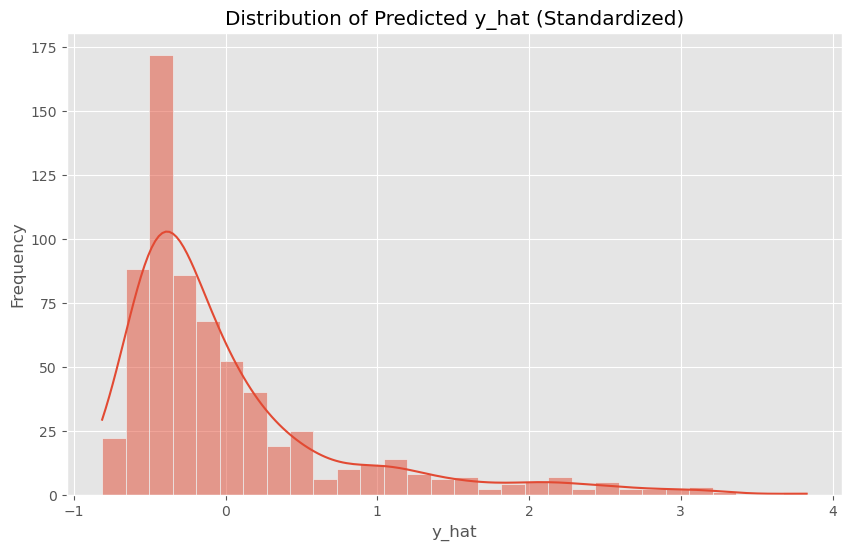

In [938]:
# Plot the distribution of y_hat
plt.figure(figsize=(10, 6))
sns.histplot(y_hat, kde=True, bins=30)
plt.title('Distribution of Predicted y_hat (Standardized)')
plt.xlabel('y_hat')
plt.ylabel('Frequency')
plt.show()

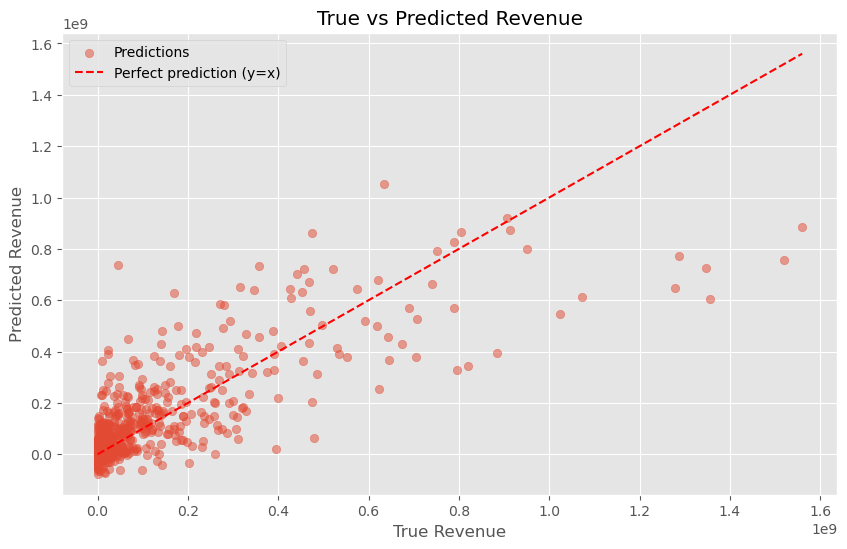

In [939]:
# Plot true vs predicted revenue with regression line
plt.figure(figsize=(10, 6))
plt.scatter(y_true, y_pred, alpha=0.5, label='Predictions')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Perfect prediction (y=x)')
plt.xlabel('True Revenue')
plt.ylabel('Predicted Revenue')
plt.title('True vs Predicted Revenue')
plt.legend()
plt.show()